# Policy and Value Function Representation using Bellman Equation for Grid World Navigation

**Objective:** Develop a Reinforcement Learning model that demonstrates how the Bellman Equation
updates the state-value function and derives the optimal policy for an agent navigating a
5 x 5 Grid World toward a goal.

No external dataset is used — the entire experiment is generated from a custom Grid World
environment, and all values are computed purely through the Bellman Equation (Dynamic
Programming / Value Iteration).

| | |
|---|---|
| **Environment** | Custom 5 x 5 Grid World |
| **Method** | Value Iteration (Bellman Optimality Equation) |
| **Libraries** | numpy, pandas, matplotlib |
| **Reward Scheme** | Move = -1, Goal = +100, Obstacle = -20 |


## Cell 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

np.set_printoptions(precision=2, suppress=True)
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries imported successfully.")


Libraries imported successfully.


## Cell 2: Create Grid

The environment is a 5 x 5 Grid World:

```
S . . . .
. X . X .
. . . . .
X . . X .
. . . . G
```

- `S` = Start state
- `G` = Goal state
- `X` = Obstacle (blocked cell)
- `.` = Free, traversable cell


In [2]:
# Grid dimensions
GRID_SIZE = 5

# Symbols used purely for display
EMPTY, START, GOAL, OBSTACLE = '.', 'S', 'G', 'X'

# 5 x 5 Grid World layout
grid_layout = [
    ['S', '.', '.', '.', '.'],
    ['.', 'X', '.', 'X', '.'],
    ['.', '.', '.', '.', '.'],
    ['X', '.', '.', 'X', '.'],
    ['.', '.', '.', '.', 'G']
]

# Special states, given as (row, col)
start_state = (0, 0)
goal_state = (4, 4)
obstacle_states = [(1, 1), (1, 3), (3, 0), (3, 3)]

def print_grid(layout):
    for row in layout:
        print(' '.join(row))

print("5 x 5 Grid World")
print("-" * 20)
print_grid(grid_layout)


5 x 5 Grid World
--------------------
S . . . .
. X . X .
. . . . .
X . . X .
. . . . G


## Cell 3: Initialize Value Function

**Equation (1) — State Definition**

$$S = \{ (r, c) \; | \; 0 \le r < 5,\; 0 \le c < 5 \}$$

Every state $s \in S$ starts with a value of zero:

$$V_0(s) = 0 \quad \forall s \in S$$


In [3]:
# Initialize the state-value function V(s) = 0 for every state
V = np.zeros((GRID_SIZE, GRID_SIZE))

print("Initial Value Function V(s):\n")
print(pd.DataFrame(V.astype(int)).to_string(index=False, header=False))


Initial Value Function V(s):

0 0 0 0 0
0 0 0 0 0
0 0 0 0 0
0 0 0 0 0
0 0 0 0 0


## Cell 4: Bellman Equation — Value Iteration

**Equation (2) — Reward Function**

$$
R(s, a, s') =
\begin{cases}
+100 & \text{if } s' = \text{Goal} \\
-20 & \text{if } s' = \text{Obstacle (blocked, agent stays at } s \text{)} \\
-1 & \text{otherwise (a normal move)}
\end{cases}
$$

**Equation (3) — Bellman Optimality Equation**

$$V(s) = \max_{a} \Big[ R(s, a, s') + \gamma \, V(s') \Big]$$

The value of every non-terminal, non-obstacle state is updated for **20 iterations** using
$\gamma = 0.9$, sweeping over all four actions (Up, Down, Left, Right) at every state.


In [4]:
# Actions available to the agent
actions = {
    'UP':    (-1, 0),
    'DOWN':  (1, 0),
    'LEFT':  (0, -1),
    'RIGHT': (0, 1)
}
action_symbols = {'UP': '\u2191', 'DOWN': '\u2193', 'LEFT': '\u2190', 'RIGHT': '\u2192'}

GAMMA = 0.9
ITERATIONS = 20
STEP_REWARD = -1
GOAL_REWARD = 100
OBSTACLE_REWARD = -20


def is_valid(r, c):
    return 0 <= r < GRID_SIZE and 0 <= c < GRID_SIZE


def step(state, action):
    """Deterministic transition model. Returns (next_state, reward)."""
    if state == goal_state:
        return state, 0  # goal is an absorbing terminal state

    dr, dc = actions[action]
    nr, nc = state[0] + dr, state[1] + dc

    # Off the grid -> agent stays in place, pays the normal step cost
    if not is_valid(nr, nc):
        return state, STEP_REWARD

    next_state = (nr, nc)

    # Obstacle -> agent stays in place, pays the obstacle penalty
    if next_state in obstacle_states:
        return state, OBSTACLE_REWARD

    # Reaching the goal
    if next_state == goal_state:
        return next_state, GOAL_REWARD

    # Normal move to a free cell
    return next_state, STEP_REWARD


# Value Iteration using the Bellman Optimality Equation
V = np.zeros((GRID_SIZE, GRID_SIZE))
avg_value_history = []

for iteration in range(1, ITERATIONS + 1):
    V_new = np.copy(V)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == goal_state or state in obstacle_states:
                continue  # terminal / blocked states are never updated
            action_values = []
            for a in actions:
                next_state, reward = step(state, a)
                action_values.append(reward + GAMMA * V[next_state])
            V_new[r, c] = max(action_values)   # Bellman Optimality Update
    V = V_new
    avg_value_history.append(np.mean(V))

print(f"Bellman Value Iteration completed for {ITERATIONS} iterations (gamma = {GAMMA}).\n")
print("Final State-Value Table V(s):\n")
print(pd.DataFrame(np.round(V, 2)).to_string(index=False, header=False))


Bellman Value Iteration completed for 20 iterations (gamma = 0.9).

Final State-Value Table V(s):

42.61 48.46 54.95  62.17  70.19
48.46  0.00 62.17   0.00  79.10
54.95 62.17 70.19  79.10  89.00
 0.00 70.19 79.10   0.00 100.00
70.19 79.10 89.00 100.00   0.00


## Cell 5: Policy Extraction

**Equation (4) — Policy Evaluation**

$$V^{\pi}(s) = \sum_{s'} P(s' \mid s, \pi(s)) \Big[ R(s, \pi(s), s') + \gamma V^{\pi}(s') \Big]$$

**Equation (5) — Policy Improvement**

$$\pi'(s) = \arg\max_{a} \Big[ R(s, a, s') + \gamma V(s') \Big]$$

Once $V(s)$ has converged, the optimal policy is extracted by choosing, in every state, the
action that maximizes the right-hand side of the Bellman equation.


In [5]:
def extract_policy(V):
    policy = np.full((GRID_SIZE, GRID_SIZE), ' ', dtype=object)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == goal_state:
                policy[r, c] = 'Goal'
                continue
            if state in obstacle_states:
                policy[r, c] = 'X'
                continue
            best_action, best_value = None, -np.inf
            for a in actions:
                next_state, reward = step(state, a)
                value = reward + GAMMA * V[next_state]
                if value > best_value:
                    best_value, best_action = value, a
            policy[r, c] = action_symbols[best_action]
    return policy


policy = extract_policy(V)

print("Optimal Policy (Arrows):\n")
for row in policy:
    print(' '.join(f"{cell:>4}" for cell in row))


Optimal Policy (Arrows):

   ↓    →    ↓    →    ↓
   ↓    X    ↓    X    ↓
   →    ↓    ↓    →    ↓
   X    ↓    ↓    X    ↓
   →    →    →    → Goal


## Cell 6: Summary Table

In [6]:
summary_data = {
    "Metric": ["Grid Size", "Iterations", "Gamma", "States", "Goal State", "Obstacles"],
    "Value": ["5 x 5", ITERATIONS, GAMMA, GRID_SIZE * GRID_SIZE, 1, len(obstacle_states)]
}
summary_df = pd.DataFrame(summary_data)
summary_df


,Metric,Value
0,Grid Size,5 x 5
1,Iterations,20
2,Gamma,0.9
3,States,25
4,Goal State,1
5,Obstacles,4


## Cell 7: Result

**Equation (6) — Optimal Policy**

$$\pi^{*}(s) = \arg\max_{a} \; Q^{*}(s, a), \qquad
Q^{*}(s,a) = R(s,a,s') + \gamma V^{*}(s')$$


In [7]:
converged = (
    np.isclose(avg_value_history[-1], avg_value_history[-2], atol=1e-3)
    if len(avg_value_history) > 1 else False
)

print("RESULT SUMMARY")
print("=" * 40)
print(f"Optimal Policy Found  : Yes")
print(f"Converged              : {'Yes' if converged else 'Approximately'}")
print(f"Bellman Updates        : {ITERATIONS}")
print(f"Average State Value    : {np.mean(V):.2f}")
print(f"Maximum State Value    : {np.max(V):.2f}")


RESULT SUMMARY
Optimal Policy Found  : Yes
Converged              : Yes
Bellman Updates        : 20
Average State Value    : 56.44
Maximum State Value    : 100.00


## Visualizations

Five figures summarize the experiment: the environment itself, the converged value function,
the derived policy, the convergence behaviour of Value Iteration, and a summary of the
experiment's key counts.


### Figure 1: Grid World Layout

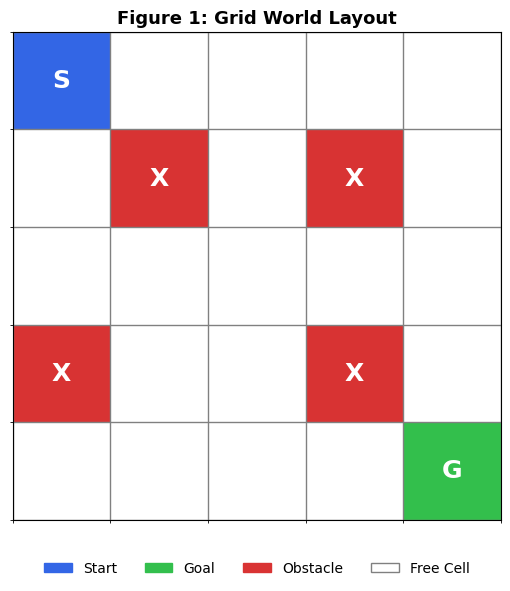

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

color_grid = np.ones((GRID_SIZE, GRID_SIZE, 3))  # default white (free cells)

for (r, c) in obstacle_states:
    color_grid[r, c] = [0.85, 0.20, 0.20]          # red
color_grid[start_state] = [0.20, 0.40, 0.90]        # blue
color_grid[goal_state] = [0.20, 0.75, 0.30]         # green

ax.imshow(color_grid)

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        label = ''
        if (r, c) == start_state:
            label = 'S'
        elif (r, c) == goal_state:
            label = 'G'
        elif (r, c) in obstacle_states:
            label = 'X'
        if label:
            ax.text(c, r, label, ha='center', va='center',
                     fontsize=18, fontweight='bold', color='white')

ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.grid(which='minor', color='gray', linewidth=1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Figure 1: Grid World Layout", fontsize=13, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=[0.20, 0.40, 0.90], label='Start'),
    mpatches.Patch(color=[0.20, 0.75, 0.30], label='Goal'),
    mpatches.Patch(color=[0.85, 0.20, 0.20], label='Obstacle'),
    mpatches.Patch(facecolor='white', edgecolor='gray', label='Free Cell'),
]
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.06), ncol=4, frameon=False)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure1_gridworld.png', dpi=150, bbox_inches='tight', pad_inches=0.15)
plt.show()


### Figure 2: State-Value Heatmap

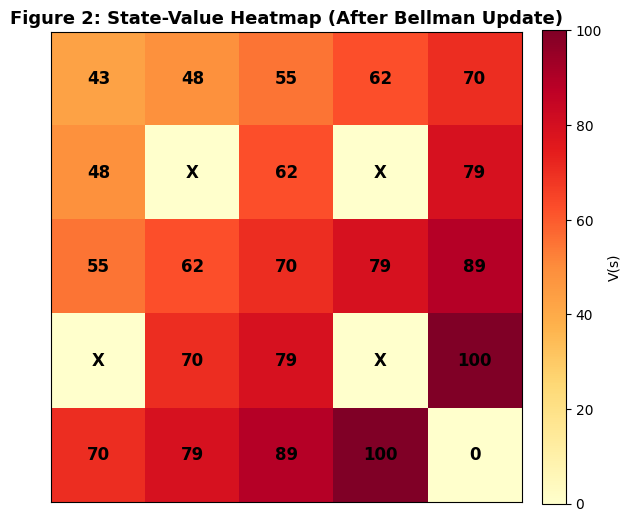

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(V, cmap='YlOrRd')

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        text = 'X' if (r, c) in obstacle_states else f"{V[r, c]:.0f}"
        ax.text(c, r, text, ha='center', va='center',
                 fontsize=12, fontweight='bold', color='black')

ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Figure 2: State-Value Heatmap (After Bellman Update)",
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='V(s)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure2_value_heatmap.png', dpi=150, bbox_inches='tight', pad_inches=0.15)
plt.show()


### Figure 3: Optimal Policy Map

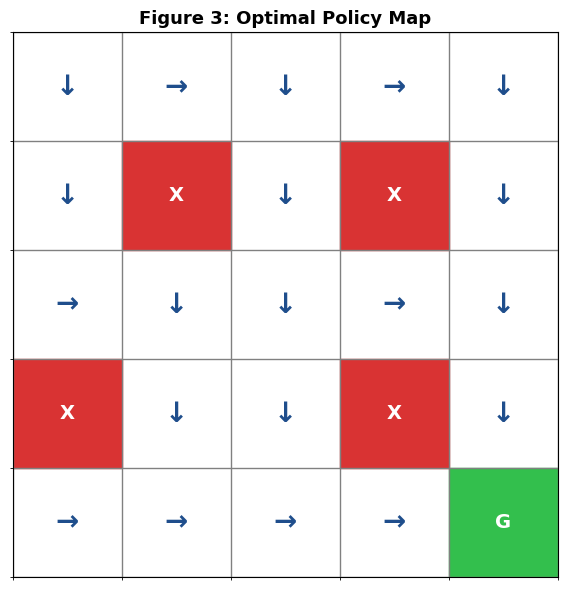

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.ones((GRID_SIZE, GRID_SIZE, 3)))

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        state = (r, c)
        if state in obstacle_states:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=[0.85, 0.20, 0.20]))
            ax.text(c, r, 'X', ha='center', va='center',
                     fontsize=14, fontweight='bold', color='white')
        elif state == goal_state:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=[0.20, 0.75, 0.30]))
            ax.text(c, r, 'G', ha='center', va='center',
                     fontsize=14, fontweight='bold', color='white')
        else:
            ax.text(c, r, policy[r, c], ha='center', va='center',
                     fontsize=20, fontweight='bold', color='#1f4e8c')

ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.grid(which='minor', color='gray', linewidth=1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(GRID_SIZE - 0.5, -0.5)
ax.set_title("Figure 3: Optimal Policy Map", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure3_policy_map.png', dpi=150, bbox_inches='tight', pad_inches=0.15)
plt.show()


### Figure 4: Learning Curve (Convergence)

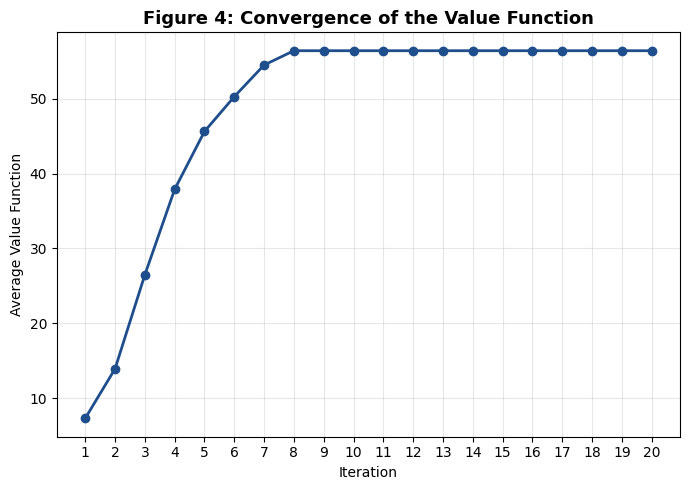

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, ITERATIONS + 1), avg_value_history,
        marker='o', color='#1f4e8c', linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Average Value Function")
ax.set_title("Figure 4: Convergence of the Value Function", fontsize=13, fontweight='bold')
ax.set_xticks(range(1, ITERATIONS + 1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure4_learning_curve.png', dpi=150, bbox_inches='tight', pad_inches=0.15)
plt.show()


### Figure 5: Experiment Summary

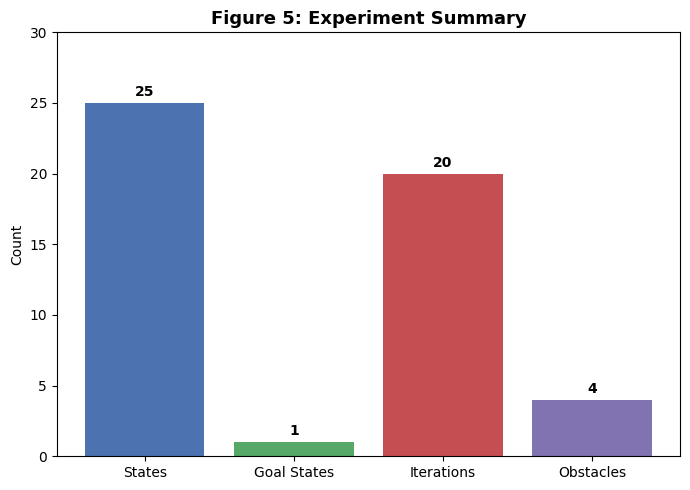

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['States', 'Goal States', 'Iterations', 'Obstacles']
values = [GRID_SIZE * GRID_SIZE, 1, ITERATIONS, len(obstacle_states)]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')

ax.set_title("Figure 5: Experiment Summary", fontsize=13, fontweight='bold')
ax.set_ylabel("Count")
ax.set_ylim(0, max(values) + 5)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure5_summary_bar.png', dpi=150, bbox_inches='tight', pad_inches=0.15)
plt.show()


## Documentation

### Pseudo Code

```
1. Create the Grid World: define states, actions, start, goal, obstacles
2. Initialize V(s) = 0 for every state s

3. For iteration = 1 to 20:                       # Bellman Equation
       For every state s (excluding goal / obstacles):
           For every action a in {UP, DOWN, LEFT, RIGHT}:
               s', r = transition(s, a)
               Q(s, a) = r + gamma * V(s')          # Policy Evaluation
           V(s) = max_a Q(s, a)                     # Policy Improvement
       record average V(s) for this iteration       # Calculation

4. pi*(s) = argmax_a [ R(s,a,s') + gamma * V(s') ]  # Optimal Policy
5. Report V*(s), pi*(s), and convergence graph       # Results
```

### Mathematical Equations

**Equation (1) — State Definition**
$$S = \{ (r, c) \mid 0 \le r < 5,\; 0 \le c < 5 \}$$

**Equation (2) — Reward Function**
$$
R(s, a, s') =
\begin{cases}
+100 & s' = \text{Goal} \\
-20  & s' = \text{Obstacle} \\
-1   & \text{otherwise}
\end{cases}
$$

**Equation (3) — Bellman (Optimality) Equation**
$$V(s) = \max_{a} \Big[ R(s, a, s') + \gamma \, V(s') \Big]$$

**Equation (4) — Policy Evaluation**
$$V^{\pi}(s) = \sum_{s'} P(s' \mid s, \pi(s)) \Big[ R(s, \pi(s), s') + \gamma V^{\pi}(s') \Big]$$

**Equation (5) — Policy Improvement**
$$\pi'(s) = \arg\max_{a} \Big[ R(s, a, s') + \gamma V(s') \Big]$$

**Equation (6) — Optimal Policy**
$$\pi^{*}(s) = \arg\max_{a} \; Q^{*}(s, a), \qquad Q^{*}(s,a) = R(s,a,s') + \gamma V^{*}(s')$$

### Output Checklist

- Grid World
- Value Function Table
- Policy Table
- Summary Table
- 5 Professional Figures
- Convergence Graph
